# MS3SEG → DiffuEx Data Prep — All-in-One

Single notebook: mounts Drive, extracts the needed archives (`registered/`, `masks/`) fresh each run, then converts to the DiffuEx format. Safe to re-run top-to-bottom after any Colab runtime restart — extraction only takes a minute or two since it's reading from Drive, not re-downloading.

## 1. Mount Drive & install unrar

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get update -qq
!apt-get install -y -qq unrar
!pip install -q SimpleITK opencv-python-headless numpy

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.1 MB/s eta 0:00:00


## 2. Extract registered volumes + abWMH masks

In [3]:
import os, subprocess

RAR_DIR = "/content/drive/MyDrive/30393475"
EXTRACT_DIR = "/content/MS3SEG_extracted"
os.makedirs(EXTRACT_DIR, exist_ok=True)

def extract_rar(rar_path, out_subdir):
    out_dir = os.path.join(EXTRACT_DIR, out_subdir)
    os.makedirs(out_dir, exist_ok=True)
    print(f"Extracting {rar_path} -> {out_dir}")
    result = subprocess.run(
        ["unrar", "x", "-o+", rar_path, out_dir + "/"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("  STDERR:", result.stderr[-2000:])
    else:
        print("  done")
    return result.returncode == 0

extract_rar(os.path.join(RAR_DIR, "MS_100_patient_registered.rar"), "registered")
extract_rar(os.path.join(RAR_DIR, "MS_100_patient_masks.rar"), "masks")

Extracting /content/drive/MyDrive/30393475/MS_100_patient_registered.rar -> /content/MS3SEG_extracted/registered
  done
Extracting /content/drive/MyDrive/30393475/MS_100_patient_masks.rar -> /content/MS3SEG_extracted/masks
  done


True

In [4]:
# Sanity check extraction succeeded before continuing
assert os.path.isdir(os.path.join(EXTRACT_DIR, "registered")), "registered/ extraction failed — check the cell above for errors"
assert os.path.isdir(os.path.join(EXTRACT_DIR, "masks")), "masks/ extraction failed — check the cell above for errors"
print("Extraction OK.")

Extraction OK.


## 3. Config

In [5]:
REG_ROOT = os.path.join(EXTRACT_DIR, "registered", "MS_100_patient_registered")
MASK_ROOT = os.path.join(EXTRACT_DIR, "masks", "MS_100_patient_masks", "abWMH_Masks")

OUT_DIR = "/content/drive/MyDrive/DiffuEx_data_MS3SEG"   # persisted to Drive
TARGET_SIZE = (512, 512)

LESION_VALUE = 255          # abWMH mask uses 255 for lesion, not 1
MIN_LESION_PIXELS = 5       # minimum lesion pixels in a slice to count as positive

LIMIT = 5   # patients to process for a test run; set to None for the full 100

## 4. Helper functions

In [6]:
import glob, csv
import numpy as np
import SimpleITK as sitk
import cv2


def load_volume(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path))  # (Z, Y, X)


def normalize_slice(sl):
    sl = sl.astype(np.float32)
    lo, hi = np.percentile(sl, 1), np.percentile(sl, 99)
    if hi <= lo:
        hi = sl.max() if sl.max() > 0 else 1.0
        lo = 0.0
    sl = np.clip((sl - lo) / (hi - lo + 1e-6), 0, 1) * 255.0
    return sl.astype(np.uint8)


def find_patient_ids():
    return sorted([d for d in os.listdir(REG_ROOT) if os.path.isdir(os.path.join(REG_ROOT, d))])


def patient_files(pid):
    pdir = os.path.join(REG_ROOT, pid)
    t1 = os.path.join(pdir, f"{pid}_T1WI_reg.nii.gz")
    t2 = os.path.join(pdir, f"{pid}_T2WI_reg.nii.gz")
    flair = os.path.join(pdir, f"{pid}_FLAIR.nii.gz")
    brain_mask = os.path.join(pdir, f"{pid}_brain_mask.nii.gz")
    mask = os.path.join(MASK_ROOT, pid, f"{pid}_abWMH_Mask.nii.gz")
    return t1, t2, flair, brain_mask, mask


def process_patient(pid, out_img_dir, out_canny_dir):
    t1_p, t2_p, flair_p, bm_p, mask_p = patient_files(pid)
    if not all(os.path.exists(p) for p in [t1_p, t2_p, flair_p, mask_p]):
        print(f"  [skip] {pid}: missing one or more required files")
        return []

    t1_vol = load_volume(t1_p)
    t2_vol = load_volume(t2_p)
    flair_vol = load_volume(flair_p)
    mask_vol = load_volume(mask_p)
    brain_vol = load_volume(bm_p) if os.path.exists(bm_p) else None

    n_slices = t1_vol.shape[0]
    rows = []

    for z in range(n_slices):
        t1 = t1_vol[z]
        t2 = t2_vol[z]
        flair = flair_vol[z]
        m = mask_vol[z]

        if brain_vol is not None:
            bm = (brain_vol[z] > 0).astype(np.float32)
            t1 = t1 * bm
            t2 = t2 * bm
            flair = flair * bm

        t1 = normalize_slice(t1)
        t2 = normalize_slice(t2)
        flair = normalize_slice(flair)

        t1 = cv2.resize(t1, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        t2 = cv2.resize(t2, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        flair = cv2.resize(flair, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)

        rgb = np.stack([t1, t2, flair], axis=-1)  # R=T1WI, G=T2WI, B=FLAIR

        filename = f"ms3seg_{pid}_slice{z:02d}.png"
        cv2.imwrite(os.path.join(out_img_dir, filename), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))

        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        cv2.imwrite(os.path.join(out_canny_dir, filename), edges)

        lesion_pixels = int((m == LESION_VALUE).sum())
        label = 1 if lesion_pixels >= MIN_LESION_PIXELS else 0
        rows.append((filename, label, lesion_pixels))

    return rows

## 5. Run the conversion

In [7]:
out_img_dir = os.path.join(OUT_DIR, "combine_without_mask")
out_canny_dir = os.path.join(OUT_DIR, "mask_crop_cannyy")
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_canny_dir, exist_ok=True)

patient_ids = find_patient_ids()
print(f"Found {len(patient_ids)} patients under {REG_ROOT}")

if LIMIT:
    patient_ids = patient_ids[:LIMIT]

all_rows = []
for pid in patient_ids:
    rows = process_patient(pid, out_img_dir, out_canny_dir)
    all_rows.extend(rows)
    n_pos = sum(1 for _, label, _ in rows if label == 1)
    print(f"  {pid}: {len(rows)} slices, {n_pos} positive (lesion) slices")

labels_csv_out = os.path.join(OUT_DIR, "labels_binary.csv")
with open(labels_csv_out, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "label"])
    for filename, label, _ in all_rows:
        writer.writerow([filename, label])

n_pos_total = sum(1 for _, label, _ in all_rows if label == 1)
print(f"\nDone. {len(all_rows)} total slices, {n_pos_total} positive ({100*n_pos_total/max(1,len(all_rows)):.1f}%)")
print(f"  Images:  {out_img_dir}")
print(f"  Canny:   {out_canny_dir}")
print(f"  Labels:  {labels_csv_out}")

Found 100 patients under /content/MS3SEG_extracted/registered/MS_100_patient_registered
  001: 20 slices, 7 positive (lesion) slices
  002: 20 slices, 10 positive (lesion) slices
  003: 20 slices, 11 positive (lesion) slices
  004: 20 slices, 10 positive (lesion) slices
  005: 20 slices, 12 positive (lesion) slices

Done. 100 total slices, 50 positive (50.0%)
  Images:  /content/drive/MyDrive/DiffuEx_data_MS3SEG/combine_without_mask
  Canny:   /content/drive/MyDrive/DiffuEx_data_MS3SEG/mask_crop_cannyy
  Labels:  /content/drive/MyDrive/DiffuEx_data_MS3SEG/labels_binary.csv


## 6. Sanity check — preview a few slices, both positive and negative

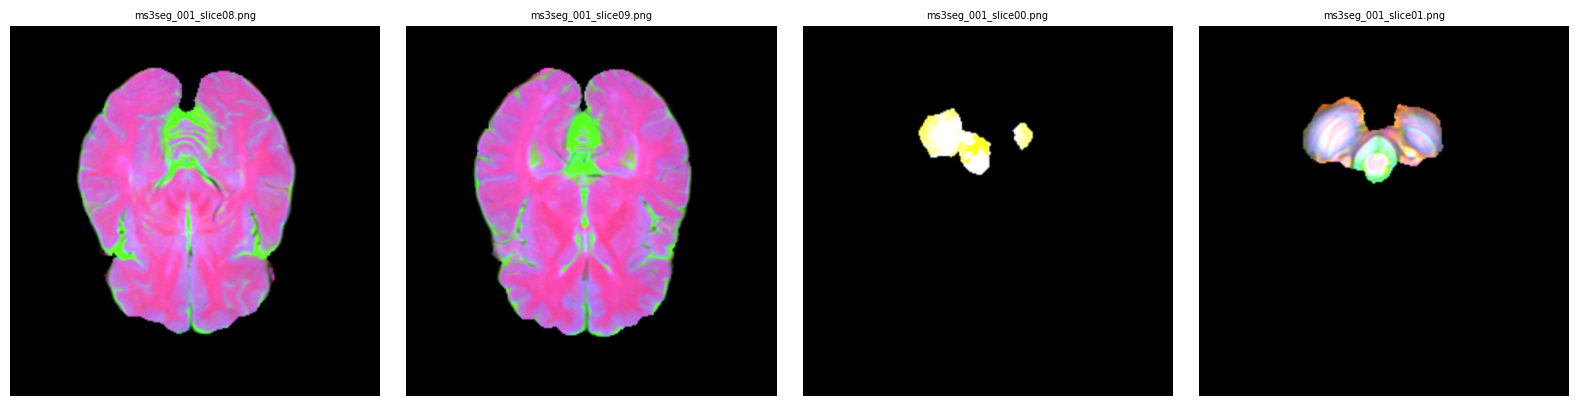

In [8]:
import matplotlib.pyplot as plt

pos_files = [f for f, label, _ in all_rows if label == 1][:2]
neg_files = [f for f, label, _ in all_rows if label == 0][:2]
sample_files = pos_files + neg_files

if not sample_files:
    print("No processed files to preview yet — check the conversion cell above ran successfully.")
else:
    fig, axes = plt.subplots(1, len(sample_files), figsize=(4*len(sample_files), 4))
    if len(sample_files) == 1:
        axes = [axes]
    for ax, fname in zip(axes, sample_files):
        img = cv2.cvtColor(cv2.imread(os.path.join(out_img_dir, fname)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(fname, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()